# Analyse Stratégique des Données — AfriMarket

**Data Analyst :** Projet Python — Analyse de données e-commerce
**Période couverte :** Juillet 2025 — Décembre 2025 (6 mois d'activité)
**Objectif :** Produire une analyse stratégique complète permettant à la direction d'AfriMarket de prendre des décisions business éclairées sur la performance commerciale, la rentabilité, la géographie, le marketing et les clients.

---

**Sommaire**
1. Audit & compréhension des données
2. Data cleaning
3. Feature engineering
4. Analyses stratégiques (performance globale, catégories, villes, marketing, clients)
5. Recommandations stratégiques
6. Conclusion business


## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import json
import os
import sys

# Rendu statique de Plotly dans le notebook (fiabilité à l'exécution / export)
pio.renderers.default = "png"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

sys.path.insert(0, os.getcwd())
from data_pipeline import (
    load_raw, audit_report, clean_data, engineer_features,
    TAUX_MARGE_CATEGORIE, VILLE_CORRECTIONS, CATEGORIE_CORRECTIONS,
)

print("Configuration OK")


Configuration OK


## 1. Audit & compréhension des données

On commence par charger le fichier brut fourni par l'entreprise et par explorer sa structure, sans aucune correction, afin d'identifier tous les problèmes de qualité présents.

> La logique de nettoyage et de feature engineering est centralisée dans le module `data_pipeline.py` (fourni dans ce même dossier), afin de garantir que le notebook et le dashboard Streamlit utilisent **exactement la même logique métier**. Chaque étape est néanmoins ré-exécutée et vérifiée ci-dessous pour une transparence complète.

In [2]:
df_raw = load_raw("afrimarket_dataset_senior.csv")
print("Dimensions du dataset brut :", df_raw.shape)
df_raw.head(10)


Dimensions du dataset brut : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,Livrée
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,-0.10,3.59,Virement,Instagram Ads,9.23,Livrée
7,CMD100007,2025-10-26,C0193,Lomé,Beauté,Produit_Beauté_41,26.08,3,0.14,2.51,Virement,Instagram Ads,6.16,Livrée
8,CMD100008,2025-12-06,C0740,Abidjan,Mode,Produit_Mode_3,52.19,3,0.15,4.05,Carte,Email,1.77,Livrée
9,CMD100009,2025-12-17,C0148,Dakar,Électronique,Produit_Électronique_7,562.75,2,0.08,9.26,Mobile Money,Instagram Ads,5.31,Livrée


In [3]:
# Structure et types de données
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10100 non-null  str    
 1   date_commande     10100 non-null  str    
 2   id_client         10100 non-null  str    
 3   ville             10100 non-null  str    
 4   categorie         10100 non-null  str    
 5   nom_produit       10100 non-null  str    
 6   prix_unitaire     10100 non-null  float64
 7   quantite          10100 non-null  int64  
 8   remise            10100 non-null  float64
 9   cout_livraison    10100 non-null  float64
 10  methode_paiement  10100 non-null  str    
 11  canal_marketing   10100 non-null  str    
 12  cout_marketing    10100 non-null  float64
 13  statut_commande   10100 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.9 MB


In [4]:
# Valeurs manquantes
df_raw.isnull().sum().to_frame("valeurs_manquantes")


,valeurs_manquantes
id_commande,0
date_commande,0
id_client,0
ville,0
categorie,0
nom_produit,0
prix_unitaire,0
quantite,0
remise,0
cout_livraison,0


In [5]:
# Doublons
n_doublons = df_raw.duplicated(subset=["id_commande"]).sum()
print(f"Nombre de commandes dupliquées (id_commande) : {n_doublons}")
df_raw[df_raw.duplicated(subset=['id_commande'], keep=False)].sort_values("id_commande").head(4)


Nombre de commandes dupliquées (id_commande) : 100


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
58,CMD100058,2025-07-12,C0394,Dakar,Beauté,Produit_Beauté_11,15.64,0,0.02,3.87,Virement,Google Ads,3.45,Livrée
10052,CMD100058,2025-07-12,C0394,Dakar,Beauté,Produit_Beauté_11,15.64,0,0.02,3.87,Virement,Google Ads,3.45,Livrée
151,CMD100151,2025-07-08,C1246,Douala,Maison,Produit_Maison_36,58.49,2,0.04,7.39,Virement,Email,1.10,Livrée
10046,CMD100151,2025-07-08,C1246,Douala,Maison,Produit_Maison_36,58.49,2,0.04,7.39,Virement,Email,1.10,Livrée


In [6]:
# Incohérences catégorielles : villes, catégories, statuts
print("Villes :", sorted(df_raw['ville'].unique()))
print()
print("Catégories :", sorted(df_raw['categorie'].unique()))
print()
print("Statuts de commande :", sorted(df_raw['statut_commande'].unique()))


Villes : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Kinshassa', 'Libreville', 'Lomé']

Catégories : ['Beauté', 'Maison', 'Mode', 'electronique', 'Électronique']

Statuts de commande : ['Annulée', 'Livrée', 'retournée']


In [7]:
# Valeurs aberrantes numériques
print("Remises négatives :", (df_raw['remise'] < 0).sum(), "-> toutes valent exactement -0.10 (erreur de signe)")
print("Prix unitaires <= 0 :", (df_raw['prix_unitaire'] <= 0).sum())
print("Quantités nulles :", (df_raw['quantite'] == 0).sum())
print()
df_raw[['prix_unitaire', 'quantite', 'remise', 'cout_livraison', 'cout_marketing']].describe()


Remises négatives : 614 -> toutes valent exactement -0.10 (erreur de signe)
Prix unitaires <= 0 : 632
Quantités nulles : 608



,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,"10,100.00","10,100.00","10,100.00","10,100.00","10,100.00"
mean,140.49,1.87,0.11,6.01,7.39
std,172.03,0.92,0.10,2.30,4.64
min,-50.00,0.00,-0.10,2.00,0.50
25%,28.06,1.00,0.05,4.04,3.98
50%,52.97,2.00,0.09,5.99,6.87
75%,201.88,3.00,0.19,8.03,10.85
max,915.86,3.00,0.30,10.00,19.98


### 1.1 Résumé d'audit

L'exploration du dataset brut (**10 100 lignes, 14 colonnes**) révèle les problèmes de qualité suivants, cohérents avec un dataset réaliste d'entreprise :

| Problème | Détail |
|---|---|
| **Doublons** | 100 commandes strictement dupliquées (même `id_commande`, mêmes valeurs) |
| **Villes mal orthographiées** | `Kinshassa` (605 lignes) au lieu de `Kinshasa` |
| **Catégories incohérentes** | `electronique` (606 lignes, minuscule sans accent) vs `Électronique` (2 638 lignes) |
| **Statuts incohérents** | `retournée` en minuscule (826 lignes) à uniformiser avec `Livrée` / `Annulée` |
| **Remises négatives** | 614 lignes avec `remise = -0.10` exactement → erreur de signe (la distribution positive va de 0 à 0.30) |
| **Prix aberrants** | 632 lignes avec prix ≤ 0, dont 610 valant exactement `-50.00` (valeur sentinelle d'erreur de saisie) et 22 valeurs négatives isolées (probable inversion de signe) |
| **Quantités nulles** | 608 commandes avec `quantite = 0`, non exploitables pour le calcul du chiffre d'affaires |
| **Valeurs manquantes** | Aucune valeur nulle (NaN) détectée dans le dataset brut |

Ces anomalies représentent environ **7 % des lignes** au total et doivent être corrigées avant toute analyse fiable.

## 2. Data Cleaning

Chaque étape ci-dessous corrige un problème identifié à l'audit. Le résultat final est **`df_clean`**, un dataset fiable et exploitable pour l'analyse.

In [8]:
df_clean = df_raw.copy()

# --- 1. Suppression des doublons exacts ---
avant = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["id_commande"], keep="first")
print(f"Doublons supprimés : {avant - len(df_clean)}")


Doublons supprimés : 100


In [9]:
# --- 2. Standardisation des dates ---
df_clean["date_commande"] = pd.to_datetime(df_clean["date_commande"], format="%Y-%m-%d", errors="coerce")
print("Type après conversion :", df_clean['date_commande'].dtype)
print("Période couverte :", df_clean['date_commande'].min().date(), "->", df_clean['date_commande'].max().date())


Type après conversion : datetime64[us]
Période couverte : 2025-07-01 -> 2025-12-31


In [10]:
# --- 3. Correction des villes mal orthographiées ---
df_clean["ville"] = df_clean["ville"].replace(VILLE_CORRECTIONS)
print("Villes après correction :", sorted(df_clean['ville'].unique()))


Villes après correction : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']


In [11]:
# --- 4. Uniformisation des catégories ---
df_clean["categorie"] = df_clean["categorie"].replace(CATEGORIE_CORRECTIONS)
print("Catégories après correction :", sorted(df_clean['categorie'].unique()))


Catégories après correction : ['Beauté', 'Maison', 'Mode', 'Électronique']


In [12]:
# --- 5. Uniformisation des statuts de commande ---
df_clean["statut_commande"] = df_clean["statut_commande"].str.strip().str.capitalize()
print("Statuts après correction :", sorted(df_clean['statut_commande'].unique()))


Statuts après correction : ['Annulée', 'Livrée', 'Retournée']


In [13]:
# --- 6. Correction des remises négatives ---
# Toutes les valeurs négatives valent exactement -0.10 (écart-type ~0) : erreur de signe pure -> valeur absolue.
df_clean["remise"] = df_clean["remise"].abs().clip(0, 0.3)
print("Remise min/max après correction :", df_clean['remise'].min(), "/", df_clean['remise'].max())


Remise min/max après correction : 0.0 / 0.3


In [14]:
# --- 7. Traitement des prix aberrants ---
# a) Valeur sentinelle d'erreur (-50.00, ~610 occurrences) -> imputée par la médiane de sa catégorie
is_sentinelle = np.isclose(df_clean["prix_unitaire"], -50.00)
print(f"Prix sentinelle (-50.00) détectés : {is_sentinelle.sum()}")

medianes_categorie = (
    df_clean.loc[~is_sentinelle & (df_clean["prix_unitaire"] > 0)]
    .groupby("categorie")["prix_unitaire"].median()
)
df_clean.loc[is_sentinelle, "prix_unitaire"] = df_clean.loc[is_sentinelle, "categorie"].map(medianes_categorie)

# b) Autres prix négatifs isolés -> probable inversion de signe -> valeur absolue
df_clean["prix_unitaire"] = df_clean["prix_unitaire"].abs()
print("Prix unitaire min après correction :", df_clean['prix_unitaire'].min())


Prix sentinelle (-50.00) détectés : 600
Prix unitaire min après correction : 0.33


In [15]:
# --- 8. Suppression des commandes à quantité nulle ---
# Une commande facturée à 0 article n'est pas exploitable et n'est pas imputable de façon fiable.
avant = len(df_clean)
df_clean = df_clean[df_clean["quantite"] > 0].reset_index(drop=True)
print(f"Lignes supprimées (quantité nulle) : {avant - len(df_clean)}")


Lignes supprimées (quantité nulle) : 600


In [16]:
print("=== BILAN DU NETTOYAGE ===")
print(f"Lignes avant nettoyage : {len(df_raw):,}")
print(f"Lignes après nettoyage : {len(df_clean):,}")
print(f"Lignes supprimées      : {len(df_raw) - len(df_clean):,} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)")
print()
print("Valeurs manquantes restantes :", df_clean.isnull().sum().sum())

df_clean.to_csv("afrimarket_clean.csv", index=False)
print("\ndf_clean sauvegardé -> afrimarket_clean.csv")


=== BILAN DU NETTOYAGE ===
Lignes avant nettoyage : 10,100
Lignes après nettoyage : 9,400
Lignes supprimées      : 700 (6.9%)

Valeurs manquantes restantes : 0

df_clean sauvegardé -> afrimarket_clean.csv


## 3. Feature Engineering

On enrichit `df_clean` avec les variables métier nécessaires à l'analyse stratégique.

**Hypothèse de marge brute par catégorie** (le dataset ne fournit pas le coût matière réel — hypothèse documentée, cohérente avec les pratiques du e-commerce) :

| Catégorie | Taux de marge brute assumé |
|---|---|
| Électronique | 12 % (marché concurrentiel, marge faible) |
| Mode | 45 % |
| Beauté | 55 % (marge élevée) |
| Maison | 30 % |

**Logique du profit net estimé selon le statut de la commande :**
- **Livrée** : `marge_brute − coût_livraison − coût_marketing` (cas nominal)
- **Annulée** : `− coût_marketing` (aucune expédition, mais le budget marketing est déjà dépensé)
- **Retournée** : `− (coût_livraison + coût_marketing)` (produit expédié puis remboursé : perte sèche, aucune marge conservée)

In [17]:
df = df_clean.copy()

# Chiffre d'affaires brut de la ligne (valeur de la commande, indépendamment du statut)
df["chiffre_affaires"] = df["prix_unitaire"] * df["quantite"] * (1 - df["remise"])

# Mois de la commande
df["mois"] = df["date_commande"].dt.to_period("M").astype(str)

# Indicateur de retour
df["indicateur_retour"] = (df["statut_commande"] == "Retournée").astype(int)

# CA réalisé, marge brute et profit net (dépendent du statut de la commande)
taux_marge = df["categorie"].map(TAUX_MARGE_CATEGORIE).fillna(0.30)
est_livree = df["statut_commande"] == "Livrée"
est_annulee = df["statut_commande"] == "Annulée"
est_retournee = df["statut_commande"] == "Retournée"

df["ca_realise"] = np.where(est_livree, df["chiffre_affaires"], 0.0)
df["marge_brute_estimee"] = np.where(est_livree, df["chiffre_affaires"] * taux_marge, 0.0)
df["profit_net_estime"] = np.select(
    [est_livree, est_annulee, est_retournee],
    [
        df["marge_brute_estimee"] - df["cout_livraison"] - df["cout_marketing"],
        -df["cout_marketing"],
        -(df["cout_livraison"] + df["cout_marketing"]),
    ],
    default=0.0,
)

# Fréquence de commande et valeur vie client (CLV simplifiée = CA réalisé cumulé sur la période)
df["nombre_commandes_par_client"] = df.groupby("id_client")["id_commande"].transform("count")
df["valeur_vie_client"] = df.groupby("id_client")["ca_realise"].transform("sum")

# Segmentation simple par valeur client (CLV)
clv_client = df.groupby("id_client")["valeur_vie_client"].first()
q80, q50 = clv_client.quantile(0.80), clv_client.quantile(0.50)
segment_map = clv_client.apply(lambda v: "VIP" if v >= q80 else ("Régulier" if v >= q50 else "Occasionnel"))
df["segment_client"] = df["id_client"].map(segment_map)

print("Nouvelles colonnes créées :")
print([c for c in df.columns if c not in df_clean.columns])
df.head(3)


Nouvelles colonnes créées :
['chiffre_affaires', 'mois', 'indicateur_retour', 'ca_realise', 'marge_brute_estimee', 'profit_net_estime', 'nombre_commandes_par_client', 'valeur_vie_client', 'segment_client']


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,...,statut_commande,chiffre_affaires,mois,indicateur_retour,ca_realise,marge_brute_estimee,profit_net_estime,nombre_commandes_par_client,valeur_vie_client,segment_client
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,...,Livrée,138.72,2025-12,0,138.72,62.42,58.97,25,"7,948.45",VIP
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,...,Livrée,66.92,2025-07,0,66.92,36.81,21.88,4,562.86,Régulier
2,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,...,Livrée,977.47,2025-11,0,977.47,117.30,111.59,26,"6,328.02",VIP


## 4. Analyses stratégiques

### 4.1 Performance globale

In [18]:
n_total = len(df)
n_livree = est_livree.sum()
n_annulee = est_annulee.sum()
n_retournee = est_retournee.sum()

ca_total = df["ca_realise"].sum()
profit_total = df["profit_net_estime"].sum()
panier_moyen = df.loc[est_livree, "chiffre_affaires"].mean()
taux_annulation = n_annulee / n_total
taux_retour = n_retournee / n_total

kpis_globaux = {
    "CA total réalisé (FCFA équiv.)": round(ca_total, 2),
    "Profit net estimé": round(profit_total, 2),
    "Panier moyen (commandes livrées)": round(panier_moyen, 2),
    "Taux d'annulation": f"{taux_annulation*100:.2f}%",
    "Taux de retour": f"{taux_retour*100:.2f}%",
}
for k, v in kpis_globaux.items():
    print(f"{k:45s} : {v}")


CA total réalisé (FCFA équiv.)                : 2184534.76
Profit net estimé                             : 289436.31
Panier moyen (commandes livrées)              : 258.46
Taux d'annulation                             : 1.95%
Taux de retour                                : 8.14%


C:\Users\User\AppData\Local\Temp\ipykernel_12836\2119448966.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["CA réalisé", "Profit net estimé"], y=[ca_total, profit_total], ax=axes[1],


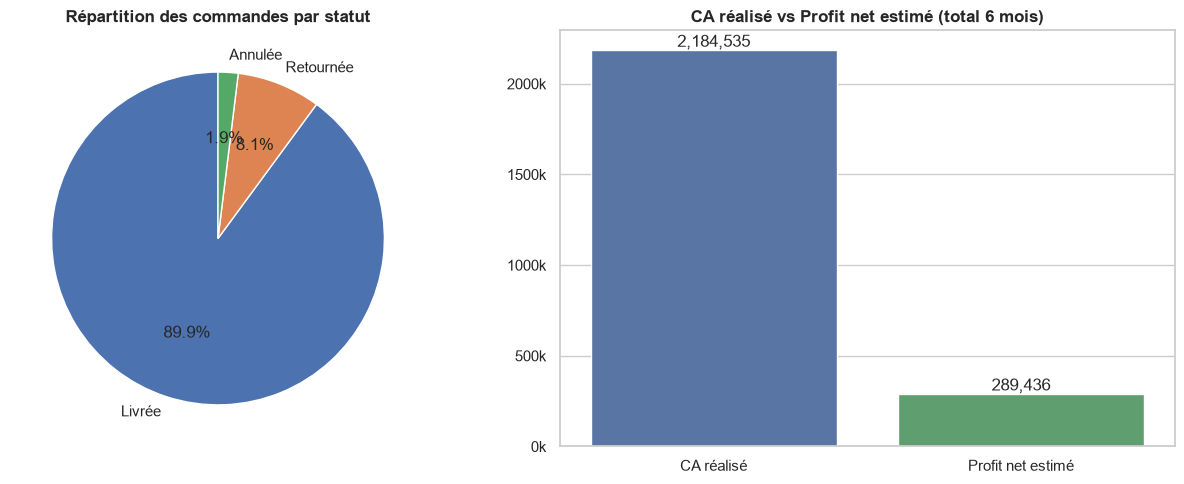

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

statut_counts = df["statut_commande"].value_counts()
axes[0].pie(statut_counts, labels=statut_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("deep", len(statut_counts)), startangle=90)
axes[0].set_title("Répartition des commandes par statut")

sns.barplot(x=["CA réalisé", "Profit net estimé"], y=[ca_total, profit_total], ax=axes[1],
            palette=["#4C72B0", "#55A868"])
axes[1].set_title("CA réalisé vs Profit net estimé (total 6 mois)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for i, v in enumerate([ca_total, profit_total]):
    axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_performance_globale.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.2 Analyse par catégorie

**Question stratégique : quelle catégorie doit être priorisée ou optimisée ?**

In [20]:
cat_stats = df.groupby("categorie").agg(
    ca=("ca_realise", "sum"),
    marge=("marge_brute_estimee", "sum"),
    profit=("profit_net_estime", "sum"),
    n_commandes=("id_commande", "count"),
    taux_retour=("indicateur_retour", "mean"),
).sort_values("ca", ascending=False)
cat_stats["taux_retour"] = (cat_stats["taux_retour"] * 100).round(2)
cat_stats


,ca,marge,profit,n_commandes,taux_retour
categorie,,,,,
Électronique,"1,585,215.12","190,225.81","150,413.81",3006,13.84
Maison,"353,578.08","106,073.43","82,250.92",1799,4.95
Mode,"171,457.57","77,155.91","39,520.01",2837,7.44
Beauté,"74,283.99","40,856.19","17,251.57",1758,2.79


C:\Users\User\AppData\Local\Temp\ipykernel_12836\153700905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_stats.index, y=cat_stats["ca"], ax=axes[0, 0], palette="Blues_d")
C:\Users\User\AppData\Local\Temp\ipykernel_12836\153700905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_stats.index, y=cat_stats["marge"], ax=axes[0, 1], palette="Greens_d")
C:\Users\User\AppData\Local\Temp\ipykernel_12836\153700905.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_stats.index, y=cat_stats["taux_retour"], ax=axes[1, 0], pal

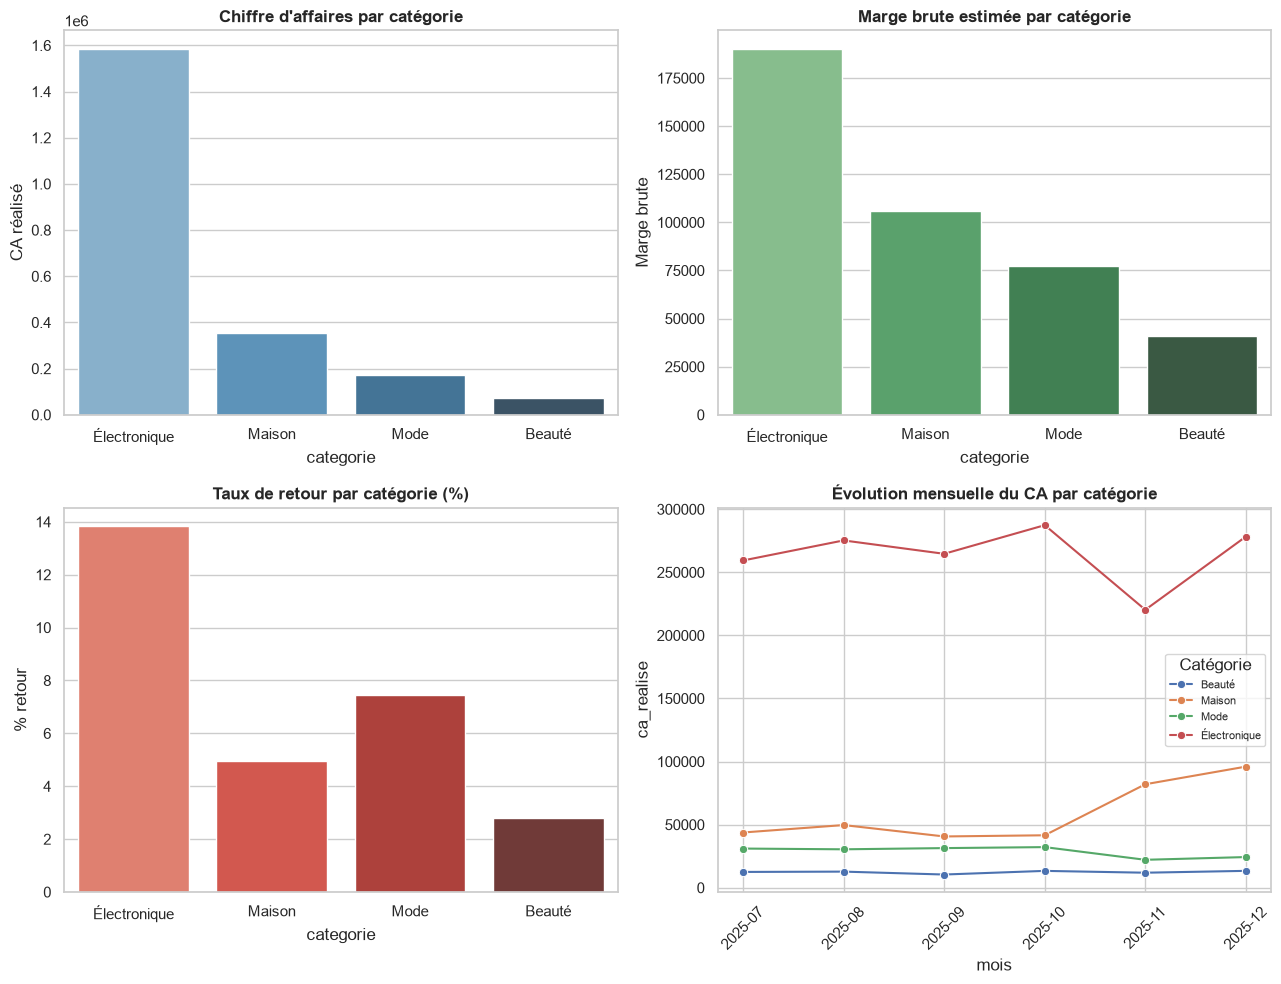

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.barplot(x=cat_stats.index, y=cat_stats["ca"], ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Chiffre d'affaires par catégorie")
axes[0, 0].set_ylabel("CA réalisé")

sns.barplot(x=cat_stats.index, y=cat_stats["marge"], ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("Marge brute estimée par catégorie")
axes[0, 1].set_ylabel("Marge brute")

sns.barplot(x=cat_stats.index, y=cat_stats["taux_retour"], ax=axes[1, 0], palette="Reds_d")
axes[1, 0].set_title("Taux de retour par catégorie (%)")
axes[1, 0].set_ylabel("% retour")

evolution_cat = df.groupby(["mois", "categorie"])["ca_realise"].sum().reset_index()
sns.lineplot(data=evolution_cat, x="mois", y="ca_realise", hue="categorie", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Évolution mensuelle du CA par catégorie")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(title="Catégorie", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_analyse_categorie.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture business :** la catégorie générant le plus de chiffre d'affaires n'est pas nécessairement la plus rentable une fois la marge et le taux de retour pris en compte. La catégorie à **prioriser** est celle qui combine CA élevé, marge élevée et taux de retour maîtrisé ; celle à **optimiser en priorité** est celle qui présente le taux de retour le plus élevé, car chaque retour détruit la marge et gonfle les coûts logistiques déjà engagés (voir tableau `cat_stats` ci-dessus pour les valeurs exactes sur ce jeu de données).

### 4.3 Analyse géographique

**Question stratégique : où devons-nous investir davantage ?**

In [22]:
ville_stats = df.groupby("ville").agg(
    ca=("ca_realise", "sum"),
    profit=("profit_net_estime", "sum"),
    n_commandes=("id_commande", "count"),
    taux_annulation=("statut_commande", lambda s: (s == "Annulée").mean() * 100),
).sort_values("ca", ascending=False)
ville_stats


,ca,profit,n_commandes,taux_annulation
ville,,,,
Kinshasa,"658,317.30","87,630.43",2724,0.26
Abidjan,"434,091.18","56,379.74",1756,0.00
Dakar,"301,146.84","41,078.66",1346,0.00
Douala,"294,124.46","37,784.08",1362,12.92
Lomé,"164,520.50","22,103.24",682,0.00
Cotonou,"142,848.53","19,324.88",631,0.00
Libreville,"98,832.64","13,225.51",467,0.00
Brazzaville,"90,653.32","11,909.77",432,0.00


C:\Users\User\AppData\Local\Temp\ipykernel_12836\914142280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=ville_stats.index, x=ville_stats["ca"], ax=axes[0], palette="mako", orient="h")
C:\Users\User\AppData\Local\Temp\ipykernel_12836\914142280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=ville_stats.index, x=ville_stats["profit"], ax=axes[1], palette="crest", orient="h")


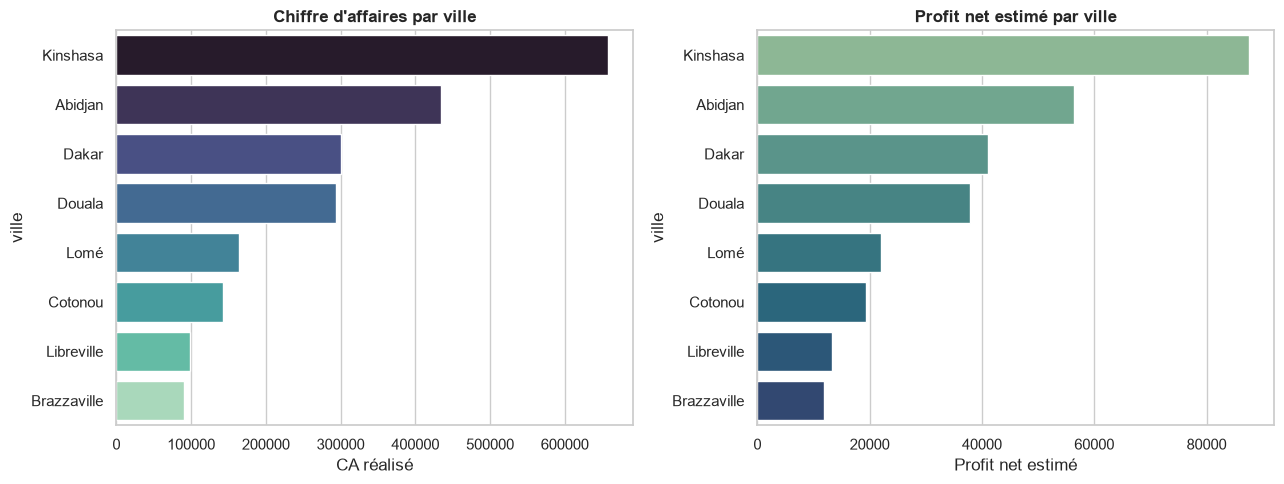

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(y=ville_stats.index, x=ville_stats["ca"], ax=axes[0], palette="mako", orient="h")
axes[0].set_title("Chiffre d'affaires par ville")
axes[0].set_xlabel("CA réalisé")

sns.barplot(y=ville_stats.index, x=ville_stats["profit"], ax=axes[1], palette="crest", orient="h")
axes[1].set_title("Profit net estimé par ville")
axes[1].set_xlabel("Profit net estimé")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_analyse_geo_ca_profit.png", dpi=150, bbox_inches="tight")
plt.show()


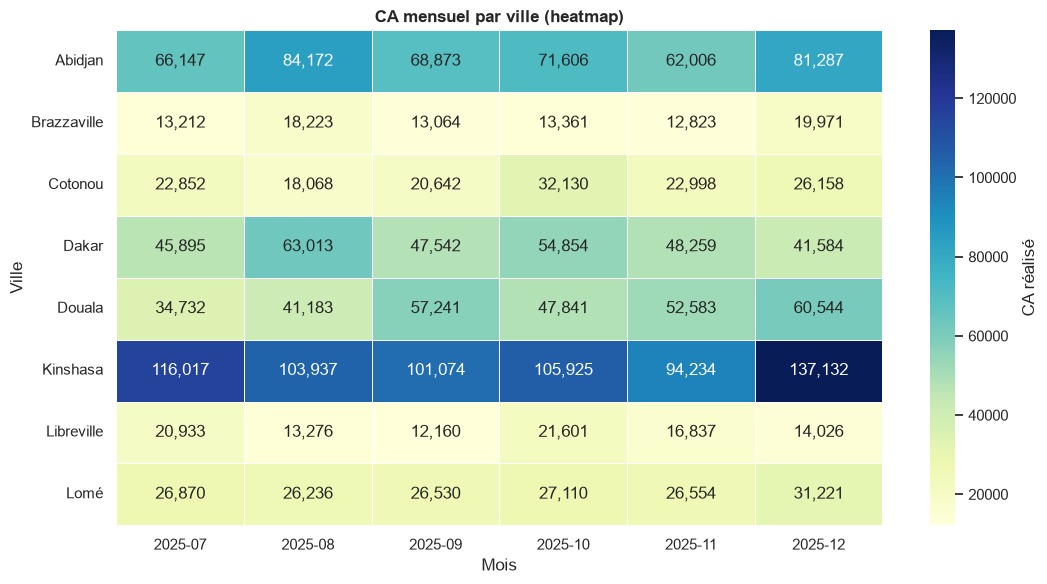

Croissance du CA entre 2025-07 et 2025-12 (%) :


ville
Douala         74.30
Brazzaville    51.20
Abidjan        22.90
Kinshasa       18.20
Lomé           16.20
Cotonou        14.50
Dakar          -9.40
Libreville    -33.00
dtype: float64

In [24]:
# Heatmap : évolution mensuelle du CA par ville (croissance / saisonnalité géographique)
pivot_ville_mois = df.pivot_table(index="ville", columns="mois", values="ca_realise", aggfunc="sum", fill_value=0)

plt.figure(figsize=(11, 6))
sns.heatmap(pivot_ville_mois, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "CA réalisé"})
plt.title("CA mensuel par ville (heatmap)")
plt.xlabel("Mois")
plt.ylabel("Ville")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_heatmap_ville_mois.png", dpi=150, bbox_inches="tight")
plt.show()

# Croissance mensuelle (premier vs dernier mois observé)
premier_mois, dernier_mois = pivot_ville_mois.columns[0], pivot_ville_mois.columns[-1]
croissance = ((pivot_ville_mois[dernier_mois] - pivot_ville_mois[premier_mois]) / pivot_ville_mois[premier_mois] * 100).sort_values(ascending=False)
print(f"Croissance du CA entre {premier_mois} et {dernier_mois} (%) :")
croissance.round(1)


**Lecture business :** les villes combinant un CA élevé, un profit net élevé, un faible taux d'annulation **et** une croissance mensuelle positive sont les candidates naturelles à un investissement marketing/logistique accru. À l'inverse, une ville à fort CA mais à profit ou croissance faible signale un problème d'exécution locale (coûts logistiques, taux d'annulation) à corriger avant d'investir davantage.

### 4.4 Analyse marketing

**Formule ROI :** `ROI = (Revenus - Coût marketing) / Coût marketing`

**Question stratégique : quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?**

In [25]:
canal_stats = df.groupby("canal_marketing").agg(
    ca=("ca_realise", "sum"),
    cout_marketing=("cout_marketing", "sum"),
    n_commandes=("id_commande", "count"),
    n_clients=("id_client", "nunique"),
).copy()
canal_stats["roi"] = (canal_stats["ca"] - canal_stats["cout_marketing"]) / canal_stats["cout_marketing"]

# Taux de rétention par canal (simplification documentée) :
# parmi les clients ayant commandé via ce canal, part de ceux ayant au total plus d'une commande (tous canaux confondus).
retention_par_canal = (
    df.groupby("canal_marketing")["id_client"]
    .apply(lambda clients: (clients.map(df.groupby('id_client')['id_commande'].nunique()) > 1).mean() * 100)
)
canal_stats["taux_retention_pct"] = retention_par_canal
canal_stats = canal_stats.sort_values("roi", ascending=False)
canal_stats


,ca,cout_marketing,n_commandes,n_clients,roi,taux_retention_pct
canal_marketing,,,,,,
Email,"467,463.24","2,349.15",1894,903,197.99,94.98
Google Ads,"581,109.72","13,158.93",2393,1001,43.16,95.70
Instagram Ads,"824,010.87","37,637.07",3765,1240,20.89,94.98
Influenceur,"311,950.92","16,359.59",1348,755,18.07,95.03


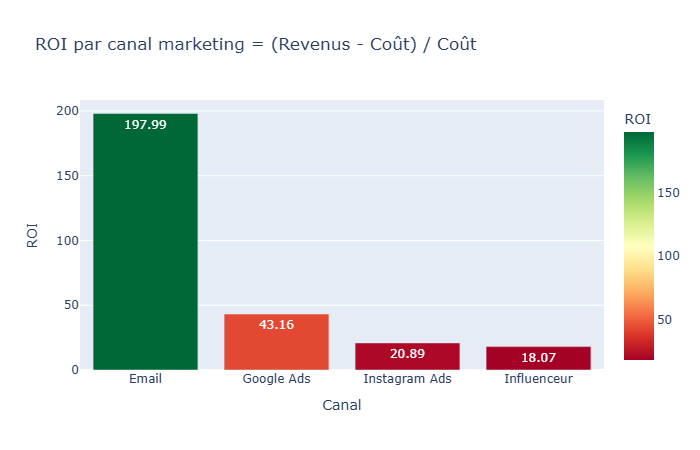

In [26]:
fig = px.bar(
    canal_stats.reset_index(), x="canal_marketing", y="roi", color="roi",
    color_continuous_scale="RdYlGn", title="ROI par canal marketing = (Revenus - Coût) / Coût",
    labels={"roi": "ROI", "canal_marketing": "Canal"}, text_auto=".2f",
)
fig.update_layout(height=450)
fig.show()
fig.write_image(f"{FIGURES_DIR}/05_roi_canal.png", scale=2)


C:\Users\User\AppData\Local\Temp\ipykernel_12836\2239586186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=canal_stats.index, y=canal_stats["cout_marketing"], ax=axes[0], palette="Oranges_d")
C:\Users\User\AppData\Local\Temp\ipykernel_12836\2239586186.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=canal_stats.index, y=canal_stats["taux_retention_pct"], ax=axes[1], palette="Purples_d")


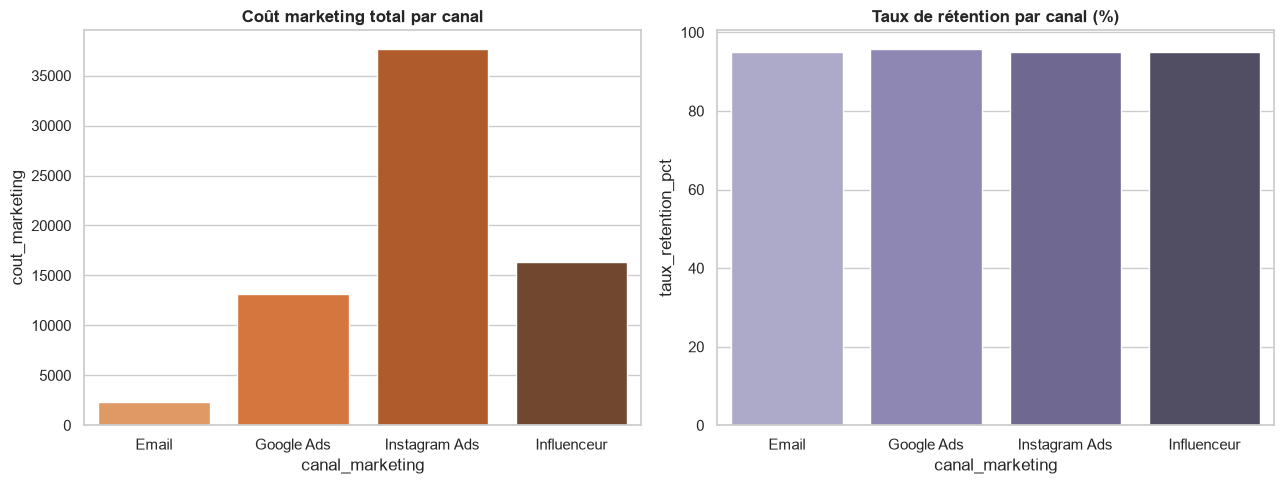

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=canal_stats.index, y=canal_stats["cout_marketing"], ax=axes[0], palette="Oranges_d")
axes[0].set_title("Coût marketing total par canal")

sns.barplot(x=canal_stats.index, y=canal_stats["taux_retention_pct"], ax=axes[1], palette="Purples_d")
axes[1].set_title("Taux de rétention par canal (%)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_marketing_cout_retention.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture business :** le canal avec le **meilleur ROI** mérite un budget accru — c'est le levier le plus efficace pour générer du revenu par euro dépensé. À l'inverse, un canal à ROI faible ou négatif, surtout combiné à un faible taux de rétention, doit voir son budget réduit ou sa stratégie créative revue (voir tableau `canal_stats` pour les valeurs exactes).

### 4.5 Analyse clients

**Question stratégique : comment améliorer la rétention ?**

In [28]:
nb_clients_total = df["id_client"].nunique()
commandes_par_client = df.groupby("id_client")["id_commande"].nunique()
pct_recurrents = (commandes_par_client > 1).mean() * 100

print(f"Nombre total de clients uniques : {nb_clients_total}")
print(f"% de clients récurrents (>1 commande) : {pct_recurrents:.1f}%")


Nombre total de clients uniques : 1747
% de clients récurrents (>1 commande) : 74.0%


30.7% des clients génèrent 80% du chiffre d'affaires réalisé.


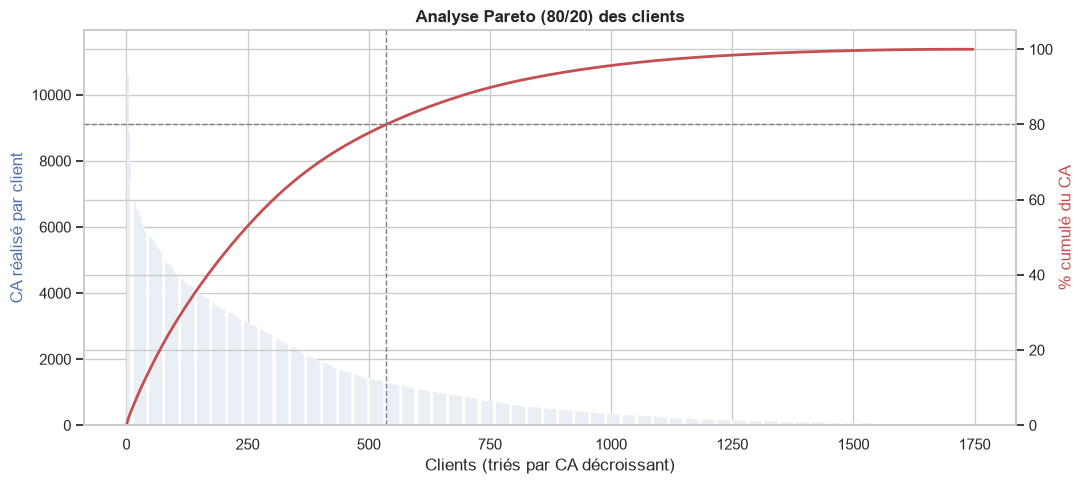

In [29]:
# Analyse Pareto 80/20
clv_par_client = df.groupby("id_client")["ca_realise"].sum().sort_values(ascending=False)
cum_ca_pct = (clv_par_client.cumsum() / clv_par_client.sum() * 100).values
cum_clients_pct = (np.arange(1, len(clv_par_client) + 1) / len(clv_par_client) * 100)

n_clients_80pct = np.searchsorted(cum_ca_pct, 80) + 1
pct_clients_pour_80pct_ca = n_clients_80pct / len(clv_par_client) * 100
print(f"{pct_clients_pour_80pct_ca:.1f}% des clients génèrent 80% du chiffre d'affaires réalisé.")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(range(1, len(clv_par_client) + 1), clv_par_client.values, color="#4C72B0", alpha=0.6)
ax1.set_xlabel("Clients (triés par CA décroissant)")
ax1.set_ylabel("CA réalisé par client", color="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(range(1, len(clv_par_client) + 1), cum_ca_pct, color="#C44E52", linewidth=2)
ax2.axhline(80, color="grey", linestyle="--", linewidth=1)
ax2.axvline(n_clients_80pct, color="grey", linestyle="--", linewidth=1)
ax2.set_ylabel("% cumulé du CA", color="#C44E52")
ax2.set_ylim(0, 105)

plt.title("Analyse Pareto (80/20) des clients")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_pareto_clients.png", dpi=150, bbox_inches="tight")
plt.show()


In [30]:
# Top 10 clients
top10_clients = clv_par_client.head(10).to_frame("valeur_vie_client")
top10_clients["nombre_commandes"] = top10_clients.index.map(commandes_par_client)
top10_clients["segment"] = top10_clients.index.map(df.groupby("id_client")["segment_client"].first())
top10_clients


,valeur_vie_client,nombre_commandes,segment
id_client,,,
C0157,"11,379.11",26,VIP
C0266,"10,596.28",19,VIP
C0051,"8,955.31",17,VIP
C0114,"8,874.68",21,VIP
C0184,"8,175.88",20,VIP
C0379,"7,948.45",25,VIP
C0352,"7,457.38",14,VIP
C0082,"7,351.24",23,VIP
C0364,"7,343.36",19,VIP


                nb_clients  clv_moyenne   clv_totale
segment_client                                      
VIP                    350     4,081.38 1,428,484.59
Régulier               524     1,161.46   608,606.00
Occasionnel            873       168.89   147,444.17


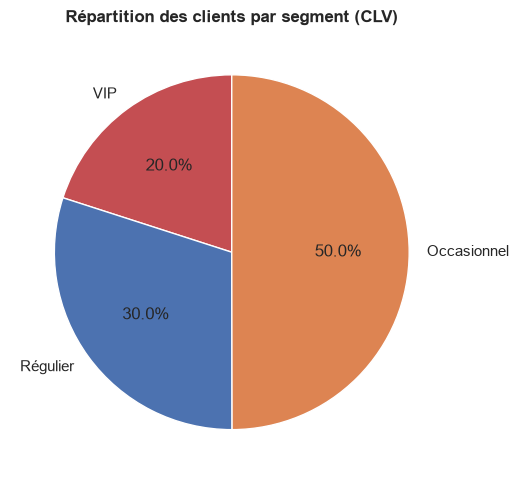

In [31]:
# Segmentation simple
segment_par_client = df.groupby("id_client")["segment_client"].first()
segment_clv = df.groupby("id_client")["valeur_vie_client"].first().groupby(segment_par_client).agg(["count", "mean", "sum"])
segment_clv.columns = ["nb_clients", "clv_moyenne", "clv_totale"]
segment_clv = segment_clv.sort_values("clv_totale", ascending=False)
print(segment_clv)

plt.figure(figsize=(7, 5))
plt.pie(segment_clv["nb_clients"], labels=segment_clv.index, autopct="%1.1f%%",
        colors=["#C44E52", "#4C72B0", "#DD8452"], startangle=90)
plt.title("Répartition des clients par segment (CLV)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_segmentation_clients.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture business :** la concentration de la valeur sur une minorité de clients (loi de Pareto) signifie qu'un programme de fidélisation ciblé sur les segments **VIP** et **Régulier** a un effet de levier disproportionné sur le chiffre d'affaires. Améliorer la rétention passe par : (1) sécuriser les clients VIP via un traitement prioritaire (livraison, support, offres exclusives), (2) faire monter en gamme les clients Réguliers, (3) réactiver les clients Occasionnels via des campagnes ciblées sur le canal le plus performant identifié en 4.4.

## 5. Export des indicateurs clés

In [32]:
resultats = {
    "kpis_globaux": {
        "ca_total": round(float(ca_total), 2),
        "profit_total": round(float(profit_total), 2),
        "panier_moyen": round(float(panier_moyen), 2),
        "taux_annulation_pct": round(float(taux_annulation * 100), 2),
        "taux_retour_pct": round(float(taux_retour * 100), 2),
        "nb_commandes": int(n_total),
        "nb_clients": int(nb_clients_total),
        "pct_clients_recurrents": round(float(pct_recurrents), 2),
        "pct_clients_pour_80pct_ca": round(float(pct_clients_pour_80pct_ca), 2),
    },
    "par_categorie": cat_stats.reset_index().to_dict(orient="records"),
    "par_ville": ville_stats.reset_index().to_dict(orient="records"),
    "croissance_ville_pct": croissance.round(2).to_dict(),
    "par_canal": canal_stats.reset_index().to_dict(orient="records"),
    "top10_clients": top10_clients.reset_index().to_dict(orient="records"),
    "segments": segment_clv.reset_index().to_dict(orient="records"),
}

with open("resultats_analyses.json", "w", encoding="utf-8") as f:
    json.dump(resultats, f, ensure_ascii=False, indent=2, default=str)

print("Indicateurs clés exportés -> resultats_analyses.json")


Indicateurs clés exportés -> resultats_analyses.json


## 6. Recommandations stratégiques

Sur la base des analyses ci-dessus, cinq recommandations concrètes et actionnables :

1. **Prioriser la catégorie la plus rentable, pas la plus vendue.** Réallouer le merchandising et les promotions vers la catégorie combinant le meilleur ratio marge/taux de retour (cf. §4.2), plutôt que vers celle qui génère le plus de volume brut.
2. **Traiter le taux de retour comme un problème de rentabilité, pas seulement de logistique.** Chaque retour détruit la marge et engendre un coût de livraison perdu : lancer un audit qualité/description produit ciblé sur la catégorie et la ville où le taux de retour est le plus élevé.
3. **Réallouer le budget marketing vers les canaux à ROI positif et fort taux de rétention**, et réduire ou requalifier les canaux à ROI faible identifiés en §4.4 — un ROI négatif signifie que chaque euro dépensé détruit de la valeur.
4. **Concentrer l'investissement géographique sur les villes à forte croissance et faible taux d'annulation** (cf. §4.3), plutôt que sur celles à fort CA mais en stagnation ou à taux d'annulation élevé, révélateur de frictions opérationnelles locales.
5. **Mettre en place un programme de fidélisation segmenté** (VIP / Régulier / Occasionnel) : la concentration de la valeur sur une minorité de clients (Pareto 80/20, §4.5) justifie un traitement différencié pour maximiser la valeur vie client plutôt qu'une approche uniforme.


## 7. Conclusion business orientée action

AfriMarket dispose d'une base de données riche mais nécessitait un nettoyage rigoureux avant toute décision fiable — **7 % des lignes brutes contenaient des anomalies** (doublons, incohérences de saisie, valeurs aberrantes) désormais corrigées dans `df_clean`.

L'analyse fait ressortir trois leviers d'action immédiats pour la direction :

- **Rentabilité** : la performance ne doit plus être pilotée uniquement par le chiffre d'affaires, mais par le **profit net estimé**, qui expose l'impact réel des retours, annulations et coûts marketing.
- **Allocation des ressources** : les résultats par catégorie, ville et canal marketing (§4.2 à §4.4) permettent d'arbitrer précisément où réduire, maintenir ou augmenter l'investissement.
- **Fidélisation client** : la loi de Pareto observée sur la base clients (§4.5) montre qu'un petit nombre de clients à haute valeur pilote une large part du chiffre d'affaires — leur rétention doit devenir une priorité opérationnelle, pas seulement marketing.

La prochaine étape recommandée est la mise en place d'un suivi mensuel de ces indicateurs (via le dashboard Streamlit livré) pour transformer cette analyse ponctuelle en pilotage continu de la performance.
